In [8]:
import os
import pandas as pd
import sys

project_root = os.path.abspath("..")   # lên 1 cấp: MIND-research

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [9]:
from src.core.Context import VectorContext
from src.urv.URV import URV
from src.recommendation.RecommendationEngine import RecommendationEngine
from src.matrix.Matrix import Metrix
import numpy as np

In [10]:
import pickle

context = VectorContext(
    os.path.join(project_root, "data", "primary", "dev_set")
)

behaviours = context.createImpressed()

vectors_dir = os.path.join(project_root, "vectors", "primary")
represent_vectors_path = os.path.join(vectors_dir, "represent_vectors.pkl")
with open(represent_vectors_path, "rb") as f:
    represented_vector = pickle.load(f)

urv = URV()


In [ ]:
def evalue_recommender(alpha, behaviours, urv, represented_vector):
    recommender = RecommendationEngine(alpha=alpha)
    metrics_sum = {
        "AUC": 0.0,
        "MRR": 0.0,
        "nDCG@5": 0.0,
        "nDCG@10": 0.0,
        "HitRate@5": 0.0,
        "HitRate@10": 0.0,
    }

    count = 0

    for behavior_id, behavior in behaviours.items():
        # Get URV
        user_vector = urv.getURV(behavior["history"], represented_vector)

        # Get candidate News form
        # MOVE THIS LOGIC TO ENGINE
        candidate_news = [
            {
                "news_id": impression["news_id"],
                "vector": represented_vector[impression["news_id"]],
                "label": impression["label"],
            }
            for impression in behavior["impressions"]
            if impression["news_id"] in represented_vector
        ]

        ranked_candidates = recommender.recommend(
            user_vector=user_vector,
            candidate_news=candidate_news,
        )

        # Calculate matric
        result = Metrix(ranked_candidates).evaluate()

        # Add result row to total
        for key in metrics_sum:
            metrics_sum[key] += result[key]
        
        # Count row + 1
        count += 1

    # Calculate averange of matric result
    metrics = {
        key: value / count
        for key, value in metrics_sum.items()
    }

    print(f"Evaluated behaviors: {count}/{len(behaviours)}")
    print(metrics)
    
    return metrics

In [13]:
alphas = [i for i in np.arange(0, 1.05, 0.05)]

tuning_results = []

for alpha in alphas:
    metrics = evalue_recommender(
        alpha,
        behaviours,
        urv,
        represented_vector
    )

    tuning_results.append({
        "alpha": alpha,
        **metrics
    })

Evaluated behaviors: 365201/365201
{'AUC': 0.5730179334229107, 'MRR': 0.30578223624486306, 'nDCG@5': np.float64(0.2841984100072831), 'nDCG@10': np.float64(0.3453610379187859), 'HitRate@5': 0.4737281661331705, 'HitRate@10': 0.6583744294237968}
Evaluated behaviors: 365201/365201
{'AUC': 0.6039760851586758, 'MRR': 0.3158074028108514, 'nDCG@5': np.float64(0.29655371988852464), 'nDCG@10': np.float64(0.3566066851798825), 'HitRate@5': 0.49287378731164483, 'HitRate@10': 0.6728897237411726}
Evaluated behaviors: 365201/365201
{'AUC': 0.611148220780856, 'MRR': 0.31978829728627456, 'nDCG@5': np.float64(0.3014876984374142), 'nDCG@10': np.float64(0.3612277190723461), 'HitRate@5': 0.5005873477892996, 'HitRate@10': 0.6790452381017577}
Evaluated behaviors: 365201/365201
{'AUC': 0.6161569008449135, 'MRR': 0.323398013070159, 'nDCG@5': np.float64(0.3055420008746857), 'nDCG@10': np.float64(0.365420993543573), 'HitRate@5': 0.5066141658976837, 'HitRate@10': 0.6849625274848645}
Evaluated behaviors: 365201/365

,Metric,Best Alpha,Best Score
0,AUC,0.80,0.631025
4,Total,0.75,0.446089
3,nDCG@10,0.75,0.426546
2,nDCG@5,0.75,0.372322
1,MRR,0.70,0.355049


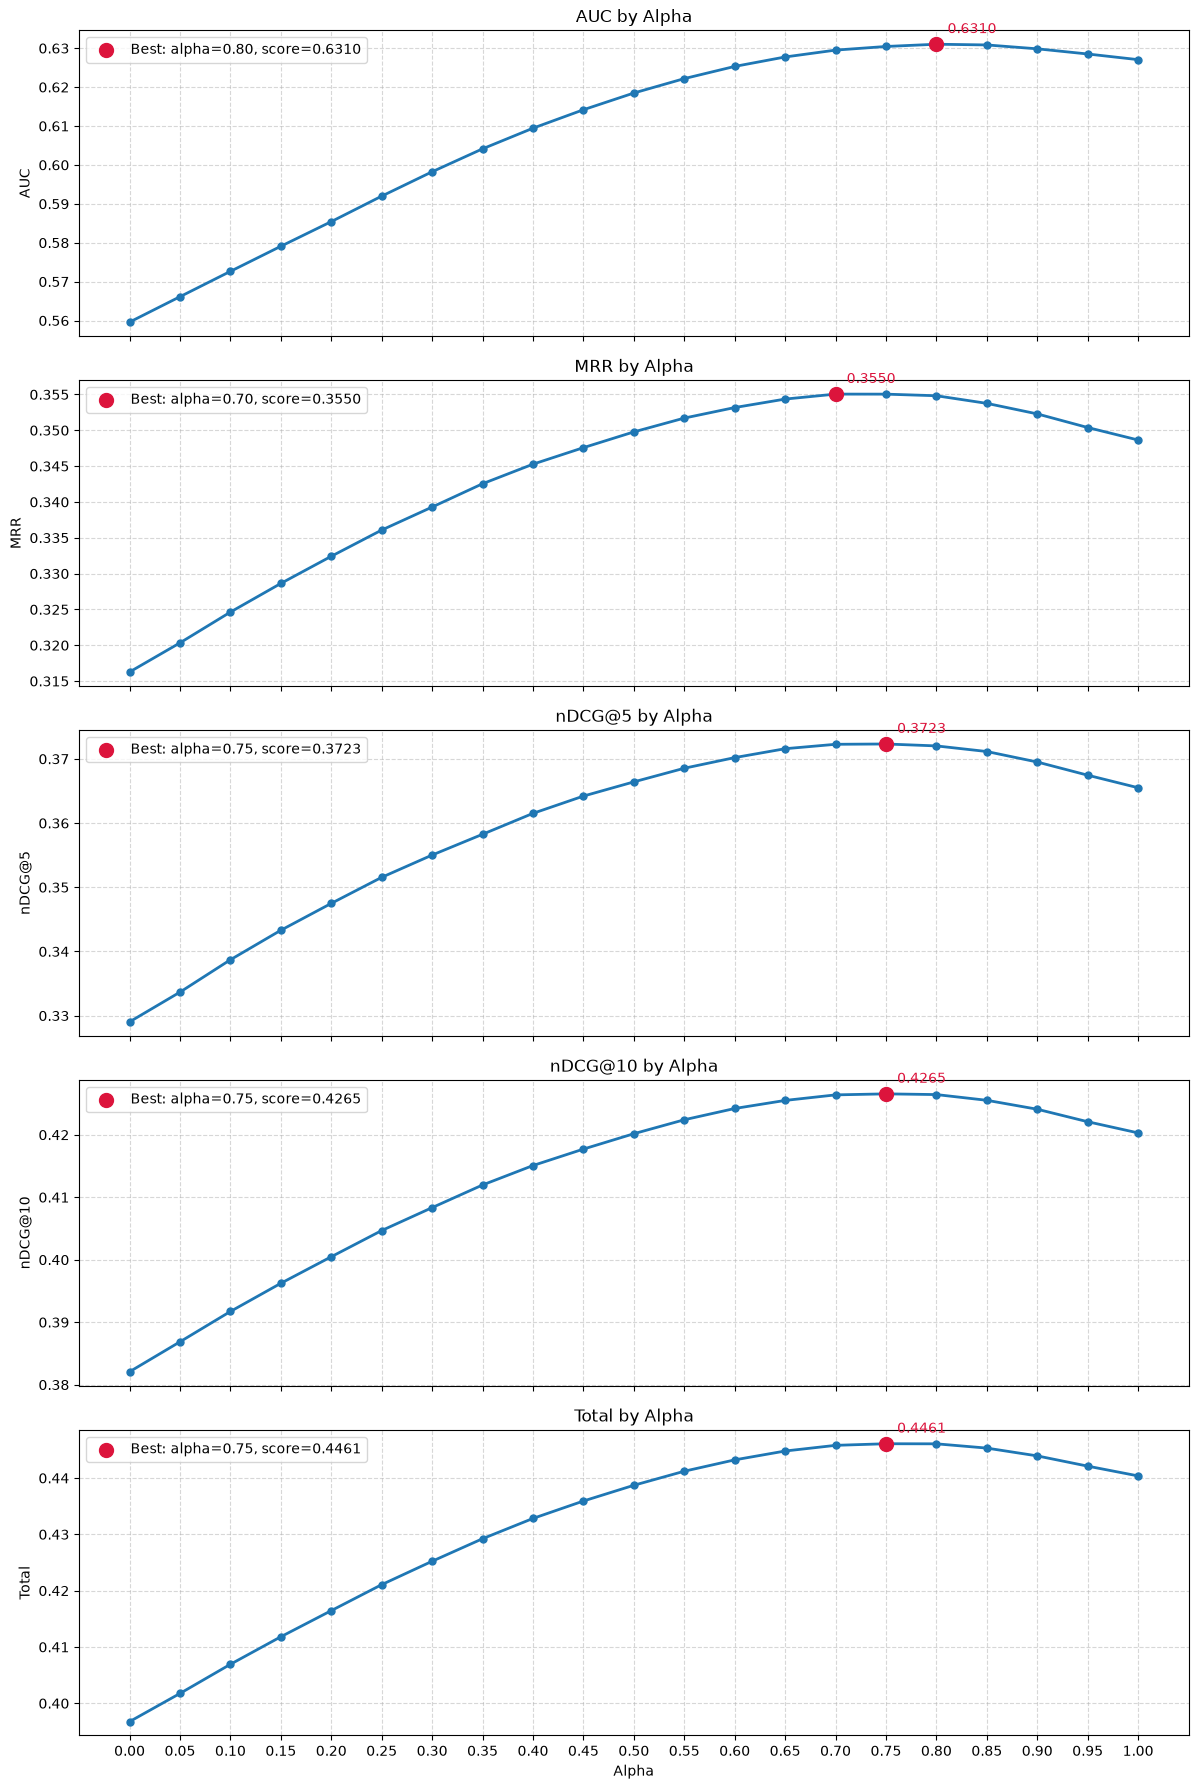

In [24]:
import matplotlib.pyplot as plt
from IPython.display import display

# Đọc kết quả tuning đã lưu
with open("../vectors/tuning_alpha_results.pkl", "rb") as f:
    tuning_results = pickle.load(f)
    

# Chuẩn hóa và sắp xếp alpha
tuning_items = sorted(
    [(float(alpha), metrics) for alpha, metrics in tuning_results.items()],
    key=lambda item: item[0]
)

alphas = [item[0] for item in tuning_items]

metrics = [
    "AUC",
    "MRR",
    "nDCG@5",
    "nDCG@10",
]

scores = {
    metric: [
        float(item[1][metric])
        for item in tuning_items
    ]
    for metric in metrics
}

# Tổng điểm là trung bình của các metrics
scores["Total"] = np.mean(
    [scores[metric] for metric in metrics],
    axis=0
)

# Bảng best score
best_scores = []

for metric, values in scores.items():
    best_idx = int(np.argmax(values))

    best_scores.append({
        "Metric": metric,
        "Best Alpha": alphas[best_idx],
        "Best Score": values[best_idx],
    })

best_scores_df = pd.DataFrame(best_scores)

display(
    best_scores_df.sort_values(
        "Best Score",
        ascending=False
    )
)

# Vẽ biểu đồ cho từng metric
fig, axes = plt.subplots(
    len(scores),
    1,
    figsize=(12, 18),
    sharex=True
)

for ax, (metric, values) in zip(axes, scores.items()):
    best_idx = int(np.argmax(values))
    best_alpha = alphas[best_idx]
    best_value = values[best_idx]

    ax.plot(
        alphas,
        values,
        marker="o",
        linewidth=2,
        markersize=5,
    )

    ax.scatter(
        best_alpha,
        best_value,
        color="crimson",
        s=100,
        zorder=3,
        label=f"Best: alpha={best_alpha:.2f}, score={best_value:.4f}",
    )

    ax.annotate(
        f"{best_value:.4f}",
        xy=(best_alpha, best_value),
        xytext=(8, 8),
        textcoords="offset points",
        color="crimson",
        fontsize=10,
    )

    ax.set_title(f"{metric} by Alpha")
    ax.set_ylabel(metric)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

axes[-1].set_xlabel("Alpha")
axes[-1].set_xticks(alphas)

plt.tight_layout()
plt.show()

In [ ]:
with open(os.path.join(project_root, "results", "tuning_results.pkl"), "rb") as f:
    tuning_df = pickle.load(f)

display(tuning_df)